# Machine Learning Work

In [969]:
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats

from numpy import sqrt
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.preprocessing import StandardScaler

In [970]:
RANDOM_SEED = 42
TEST_RATIO = 0.2
DATA_BASE_PATH = Path("./data")
POI_DATA_BASE_PATH = Path("./poi-data")
TARGET = "price"
K_FOLDS = 5

In [971]:
rent_path = DATA_BASE_PATH / "apartments_for_rent_classified_10K.csv"
poi_count_path = (
    POI_DATA_BASE_PATH / "poi-data-count-5d44b231d67f516b837067ff178d5c01.parquet"
)

In [972]:
rent = pd.read_csv(rent_path, sep=";", encoding="latin1", dtype={"id": str})
rent.head()

,id,category,title,body,amenities,bathrooms,bedrooms,currency,fee,has_photo,...,price_display,price_type,square_feet,address,cityname,state,latitude,longitude,source,time
0,5668626895,housing/rent/apartment,"Studio apartment 2nd St NE, Uhland Terrace NE,...","This unit is located at second St NE, Uhland T...",NaN,NaN,0.0,USD,No,Thumbnail,...,$790,Monthly,101,NaN,Washington,DC,38.9057,-76.9861,RentLingo,1577359415
1,5664597177,housing/rent/apartment,Studio apartment 814 Schutte Road,"This unit is located at 814 Schutte Road, Evan...",NaN,NaN,1.0,USD,No,Thumbnail,...,$425,Monthly,106,814 Schutte Rd,Evansville,IN,37.9680,-87.6621,RentLingo,1577017063
2,5668626833,housing/rent/apartment,"Studio apartment N Scott St, 14th St N, Arling...","This unit is located at N Scott St, 14th St N,...",NaN,1.0,0.0,USD,No,Thumbnail,...,"$1,390",Monthly,107,NaN,Arlington,VA,38.8910,-77.0816,RentLingo,1577359410
3,5659918074,housing/rent/apartment,Studio apartment 1717 12th Ave,"This unit is located at 1717 12th Ave, Seattle...",NaN,1.0,0.0,USD,No,Thumbnail,...,$925,Monthly,116,1717 12th Avenue,Seattle,WA,47.6160,-122.3275,RentLingo,1576667743
4,5668626759,housing/rent/apartment,"Studio apartment Washington Blvd, N Cleveland ...","This unit is located at Washington Blvd, N Cle...",NaN,NaN,0.0,USD,No,Thumbnail,...,$880,Monthly,125,NaN,Arlington,VA,38.8738,-77.1055,RentLingo,1577359401


In [973]:
rent.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             10000 non-null  object 
 1   category       10000 non-null  object 
 2   title          10000 non-null  object 
 3   body           10000 non-null  object 
 4   amenities      6451 non-null   object 
 5   bathrooms      9966 non-null   float64
 6   bedrooms       9993 non-null   float64
 7   currency       10000 non-null  object 
 8   fee            10000 non-null  object 
 9   has_photo      10000 non-null  object 
 10  pets_allowed   5837 non-null   object 
 11  price          10000 non-null  int64  
 12  price_display  10000 non-null  object 
 13  price_type     10000 non-null  object 
 14  square_feet    10000 non-null  int64  
 15  address        6673 non-null   object 
 16  cityname       9923 non-null   object 
 17  state          9923 non-null   object 
 18  latitud

## Data Cleaning

In this part of the notebook, we will clean the data. We will remove any unnecessary columns, handle missing values, and ensure that the data is in a format suitable for further analysis.

### Drop unnecessary columns

In [974]:
"""
features_to_drop is a list of columns that are not useful for the model.
The reason for dropping each column is one of the following:
- R1: Irrelevant: the column is not relevant to the model.
- R2: Redundant: the column is redundant with another column.
- R3: Need more features: the column needs more features to be useful.
- R4: Biased: the column is biased on the source.
- R6: Not useful: the column is not useful to predict the price of the property rent itself.
- R7: Unique value: the column has only one unique value.
- R8: Too many unique values: the column has too many unique values to be useful.
"""
features_to_drop = [
    # "id",  # R1: Irrelevant
    "time",  # R1: Irrelevant
    "source",  # R4: Biased
    "latitude",  # R3: Need more features to relate the location to the price
    "longitude",  # R3: Need more features to relate the location to the price
    "price_display",  # R2: Redundant with the price column
    "has_photo",  # R6: Not useful
    "fee",  # R7: Unique value
    "currency",  # R7: Unique value
    "address",  # R3: Need more features to relate the location to the price
    "cityname",  # R8: Low cardinality
    "body",  # R1: Irrelevant
    "title",  # R1: Irrelevant
]

rent.drop(columns=features_to_drop, inplace=True)
rent

,id,category,amenities,bathrooms,bedrooms,pets_allowed,price,price_type,square_feet,state
0,5668626895,housing/rent/apartment,NaN,NaN,0.0,NaN,790,Monthly,101,DC
1,5664597177,housing/rent/apartment,NaN,NaN,1.0,NaN,425,Monthly,106,IN
2,5668626833,housing/rent/apartment,NaN,1.0,0.0,NaN,1390,Monthly,107,VA
3,5659918074,housing/rent/apartment,NaN,1.0,0.0,NaN,925,Monthly,116,WA
4,5668626759,housing/rent/apartment,NaN,NaN,0.0,NaN,880,Monthly,125,VA
...,...,...,...,...,...,...,...,...,...,...
9995,5630240092,housing/rent/apartment,NaN,4.0,5.0,NaN,6000,Monthly,6300,MN
9996,5668640983,housing/rent/apartment,NaN,8.0,6.0,NaN,25000,Monthly,8716,CA
9997,5668643292,housing/rent/apartment,NaN,8.5,6.0,NaN,11000,Monthly,11318,MD
9998,5668662559,housing/rent/apartment,"Basketball,Cable or Satellite,Doorman,Hot Tub,...",NaN,1.0,NaN,4790,Monthly,40000,NY


### Drop rows with missing values

In [975]:
post_processing_features = [
    TARGET,  # target variable
    "pets_allowed",  # will be one-hot encoded
    "amenities",  # will have nlp processing
]

dropna_cols = set(rent.columns) - set(post_processing_features)

rent = rent.dropna(subset=dropna_cols)
rent.shape

(9883, 10)

In [976]:
def filter_column(df: pd.DataFrame, column: str, filter_value: str) -> pd.DataFrame:
    """
    Filter a dataframe by a column and a value.
    """
    df = df.loc[df[column] == filter_value]
    if df.empty:
        raise ValueError(f"Column {column} has no values for {filter_value}")
    return df

In [977]:
rent = filter_column(rent, "price_type", "Monthly")  # Few rows with other values (< 1%)
rent = rent.drop(columns=["price_type"])
rent.shape

(9882, 9)

In [978]:
rent = filter_column(
    rent, "category", "housing/rent/apartment"
)  # Few rows with other values (< 1%)
rent = rent.drop(columns=["category"])
rent.shape

(9879, 8)

### Remove outliers

In [979]:
def iqr_outlier_bounds(series: pd.Series) -> tuple[float, float]:
    """
    Calculate the IQR outlier bounds for a given series.
    The function returns a tuple with the lower and upper bounds.
    """
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    return lower_bound, upper_bound


def detect_outliers(df: pd.DataFrame) -> pd.DataFrame:
    """
    Detect outliers in the dataframe.
    The function uses the IQR method to detect outliers.
    The function returns a dataframe with the following columns:
    - column: the name of the column
    - lower_bound: the lower bound of the IQR
    - upper_bound: the upper bound of the IQR
    - outliers_percentage: the percentage of outliers in the column
    The function only considers columns with numeric data types (float64 and int64).
    The function returns an empty dataframe if there are no outliers.
    """
    detected_outliers: list[dict] = []
    for col in df.select_dtypes(include=["float64", "int64"]).columns:
        lower_bound, upper_bound = iqr_outlier_bounds(df[col])
        outlier_mask = ~df[col].between(lower_bound, upper_bound)
        if outlier_mask.empty:
            continue
        outlier_percentage = outlier_mask.sum() / len(df[col]) * 100
        detected_outliers.append(
            {
                "column": col,
                "lower_bound": lower_bound,
                "upper_bound": upper_bound,
                "outliers_percentage": outlier_percentage,
                "count": outlier_mask.sum(),
            }
        )
    return pd.DataFrame(detected_outliers)

In [980]:
def show_boxplot(
    df: pd.DataFrame, columns: str | list[str], title: str, log_scale: bool = False
) -> None:
    """
    Show a boxplot of the given columns in the dataframe.
    The function takes the following parameters:
    - df: the dataframe to plot
    - columns: the columns to plot
    - title: the title of the plot
    - log_scale: whether to use a log scale for the x-axis
    """
    plt.figure(figsize=(8, len(columns) / 2))
    plt.title(title)
    if isinstance(columns, str):
        columns = [columns]
    data = [df[col].dropna() for col in columns]
    plt.boxplot(data, vert=False, tick_labels=columns)
    if log_scale:
        plt.xscale("log")
    plt.xlabel("Values")
    plt.ylabel("Features")
    plt.yticks(rotation=45)  # Rotate the label names
    plt.tight_layout()
    plt.show()

In [981]:
detected_outliers = detect_outliers(rent)
outliers_columns = detected_outliers["column"].tolist()

detected_outliers.sort_values(by="outliers_percentage", ascending=False)

,column,lower_bound,upper_bound,outliers_percentage,count
3,square_feet,-25.0,1775.0,6.235449,616
2,price,-170.0,2814.0,6.164592,609
1,bedrooms,-0.5,3.5,5.162466,510
0,bathrooms,-0.5,3.5,0.728819,72


In [982]:
detected_outliers["count"].sum()

np.int64(1807)

In [983]:
rent[outliers_columns].describe()

,bathrooms,bedrooms,price,square_feet
count,9879.000000,9879.000000,9879.000000,9879.000000
mean,1.380605,1.747140,1487.236866,943.357121
std,0.616095,0.941837,1078.712272,527.206860
min,1.000000,0.000000,200.000000,107.000000
25%,1.000000,1.000000,949.000000,650.000000
50%,1.000000,2.000000,1275.000000,803.000000
75%,2.000000,2.000000,1695.000000,1100.000000
max,8.500000,9.000000,52500.000000,11318.000000


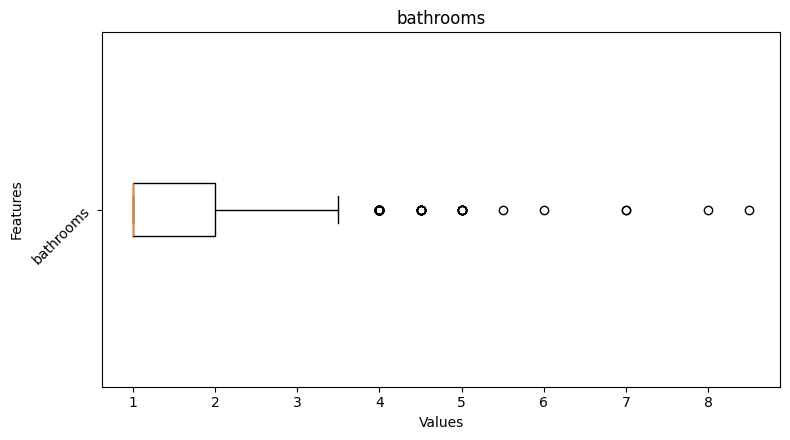

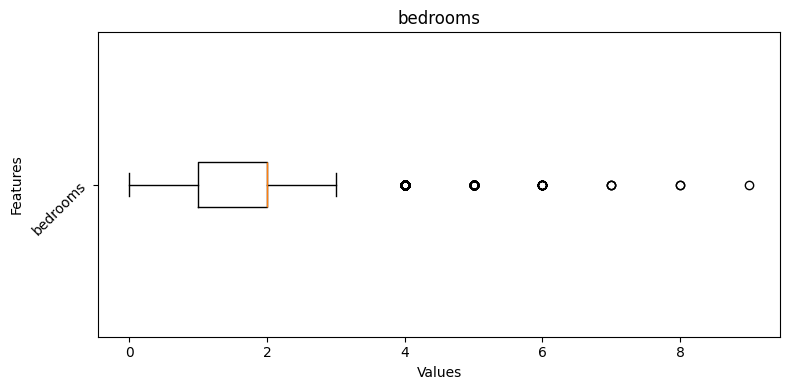

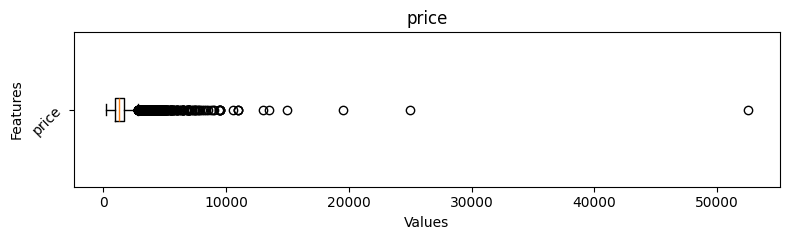

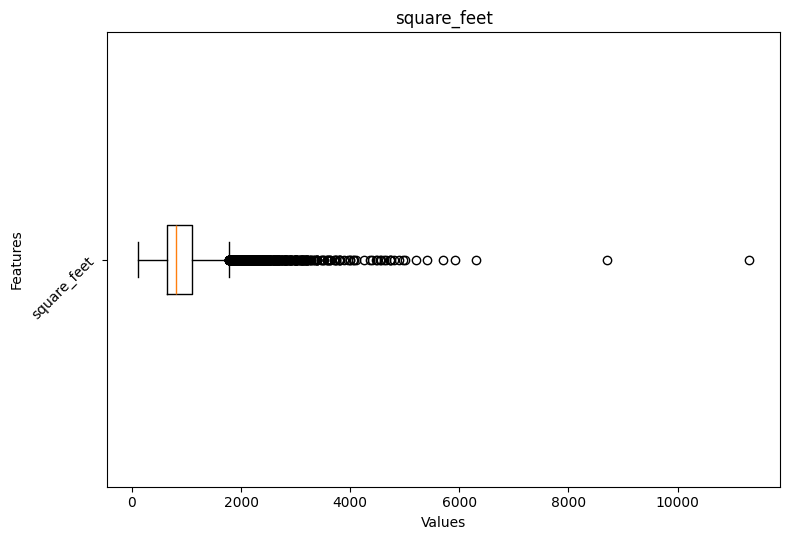

In [984]:
for col in outliers_columns:
    show_boxplot(rent, col, col)

In [985]:
def remove_outliers(
    df: pd.DataFrame, column: str, lower_bound: float, upper_bound: float
) -> pd.DataFrame:
    """
    Remove outliers from the dataframe.
    The function uses the IQR method to detect outliers.
    """
    return df[df[column].between(lower_bound, upper_bound)]

In [986]:
rent.shape

(9879, 8)

In [987]:
for col in outliers_columns:
    lower_bound, upper_bound = iqr_outlier_bounds(rent[col])
    rent = remove_outliers(rent, col, lower_bound, upper_bound)

rent = rent.reset_index(drop=True)
rent.shape

(8490, 8)

### Convert categorical variables to numerical

In [988]:
def one_hot_encode_column(
    df: pd.DataFrame, column: str, drop_first: bool = False
) -> pd.DataFrame:
    """
    One-hot encode a given column in the dataframe.
    The function returns the dataframe with the one-hot encoded column.
    """
    df = df.copy()
    encoder = OneHotEncoder(
        sparse_output=False,
        drop="first" if drop_first else None,
        handle_unknown="ignore",
    )
    encoded_column = encoder.fit_transform(df[[column]])
    encoded_df = pd.DataFrame(
        encoded_column, columns=encoder.get_feature_names_out([column])
    )
    df = df.join(encoded_df)
    df = df.drop(columns=column)
    return df

In [989]:
rent["pets_allowed"] = rent["pets_allowed"].fillna("No")

rent = one_hot_encode_column(rent, column="pets_allowed", drop_first=False)

rent.head()

,id,amenities,bathrooms,bedrooms,price,square_feet,state,pets_allowed_Cats,"pets_allowed_Cats,Dogs",pets_allowed_Dogs,pets_allowed_No
0,5668626833,NaN,1.0,0.0,1390,107,VA,0.0,0.0,0.0,1.0
1,5659918074,NaN,1.0,0.0,925,116,WA,0.0,0.0,0.0,1.0
2,5667891676,"Dishwasher,Elevator,Patio/Deck,Pool,Storage",1.0,0.0,2475,130,NY,0.0,0.0,0.0,1.0
3,5668610290,Refrigerator,1.0,0.0,1495,138,CA,0.0,0.0,0.0,1.0
4,5664571820,Refrigerator,1.0,0.0,1695,190,CA,0.0,0.0,0.0,1.0


In [990]:
rent = one_hot_encode_column(rent, column="state", drop_first=False)
rent.head()

,id,amenities,bathrooms,bedrooms,price,square_feet,pets_allowed_Cats,"pets_allowed_Cats,Dogs",pets_allowed_Dogs,pets_allowed_No,...,state_SD,state_TN,state_TX,state_UT,state_VA,state_VT,state_WA,state_WI,state_WV,state_WY
0,5668626833,NaN,1.0,0.0,1390,107,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,5659918074,NaN,1.0,0.0,925,116,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,5667891676,"Dishwasher,Elevator,Patio/Deck,Pool,Storage",1.0,0.0,2475,130,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,5668610290,Refrigerator,1.0,0.0,1495,138,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5664571820,Refrigerator,1.0,0.0,1695,190,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [991]:
rent["amenities"] = rent["amenities"].fillna("Unknown").str.split(",")
apartment_amenities = rent["amenities"].explode().unique()
apartment_amenities

array(['Unknown', 'Dishwasher', 'Elevator', 'Patio/Deck', 'Pool',
       'Storage', 'Refrigerator', 'AC', 'Basketball',
       'Cable or Satellite', 'Gym', 'Internet Access', 'Clubhouse',
       'Parking', 'Garbage Disposal', 'Fireplace', 'Washer Dryer',
       'Playground', 'Gated', 'Hot Tub', 'Tennis', 'Wood Floors', 'View',
       'Alarm', 'TV', 'Doorman', 'Luxury', 'Golf'], dtype=object)

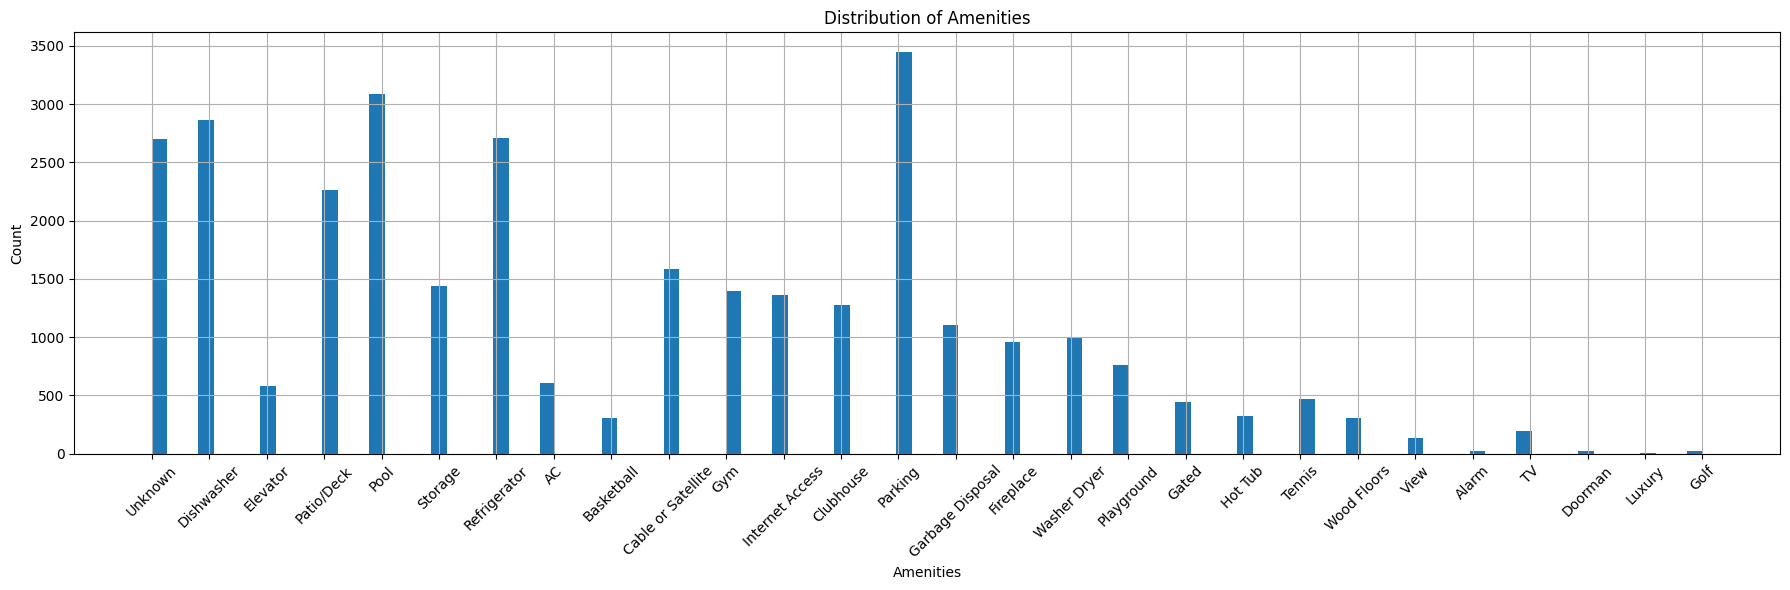

In [992]:
def plot_amenities_distribution(amenties: pd.Series) -> None:
    """
    Plot the distribution of the amenities in the dataframe.
    The function takes the following parameters:
    - df: the dataframe to plot
    - column: the column to plot
    - title: the title of the plot
    """
    plt.figure(figsize=(18, 6))
    data = amenties.explode()
    data.hist(bins=100)
    plt.title("Distribution of Amenities")
    plt.xlabel("Amenities")
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


plot_amenities_distribution(rent["amenities"])

In [993]:
def multi_label_binarize_column(df: pd.DataFrame, column: str) -> pd.DataFrame:
    """
    Multi-label binarize a given column in the dataframe.
    The column is expected to contain lists of values.
    The function returns the dataframe with the multi-label binarized column.
    """
    df = df.copy()

    mlb = MultiLabelBinarizer(sparse_output=False)

    encoded = mlb.fit_transform(df[column])
    encoded_df = pd.DataFrame(encoded, columns=mlb.classes_, index=df.index)
    df = df.join(encoded_df)
    df = df.drop(columns=column)
    return df

In [994]:
rent = multi_label_binarize_column(rent, column="amenities")
rent.head()

,id,bathrooms,bedrooms,price,square_feet,pets_allowed_Cats,"pets_allowed_Cats,Dogs",pets_allowed_Dogs,pets_allowed_No,state_AK,...,Playground,Pool,Refrigerator,Storage,TV,Tennis,Unknown,View,Washer Dryer,Wood Floors
0,5668626833,1.0,0.0,1390,107,0.0,0.0,0.0,1.0,0.0,...,0,0,0,0,0,0,1,0,0,0
1,5659918074,1.0,0.0,925,116,0.0,0.0,0.0,1.0,0.0,...,0,0,0,0,0,0,1,0,0,0
2,5667891676,1.0,0.0,2475,130,0.0,0.0,0.0,1.0,0.0,...,0,1,0,1,0,0,0,0,0,0
3,5668610290,1.0,0.0,1495,138,0.0,0.0,0.0,1.0,0.0,...,0,0,1,0,0,0,0,0,0,0
4,5664571820,1.0,0.0,1695,190,0.0,0.0,0.0,1.0,0.0,...,0,0,1,0,0,0,0,0,0,0


In [995]:
poi_count = pd.read_parquet(poi_count_path)
poi_count

,id,tag,count,type
0,5668626895,pub,4,amenity
1,5668626895,restaurant,28,amenity
2,5668626895,fast_food,9,amenity
3,5668626895,museum,1,tourism
4,5668626895,bar,13,amenity
...,...,...,...,...
56945,5668662559,music_school,1,amenity
56946,5668662559,cinema,3,amenity
56947,5668662559,dancing_school,1,amenity
56948,5668662559,prep_school,2,amenity


In [996]:
poi_count.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56950 entries, 0 to 56949
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      56950 non-null  object
 1   tag     56950 non-null  object
 2   count   56950 non-null  int64 
 3   type    56950 non-null  object
dtypes: int64(1), object(3)
memory usage: 1.7+ MB


In [997]:
poi_count.describe()

,count
count,56950.000000
mean,5.074732
std,12.257293
min,1.000000
25%,1.000000
50%,2.000000
75%,5.000000
max,585.000000


In [998]:
poi_count[["tag"]].describe()

,tag
count,56950
unique,55
top,school
freq,7870


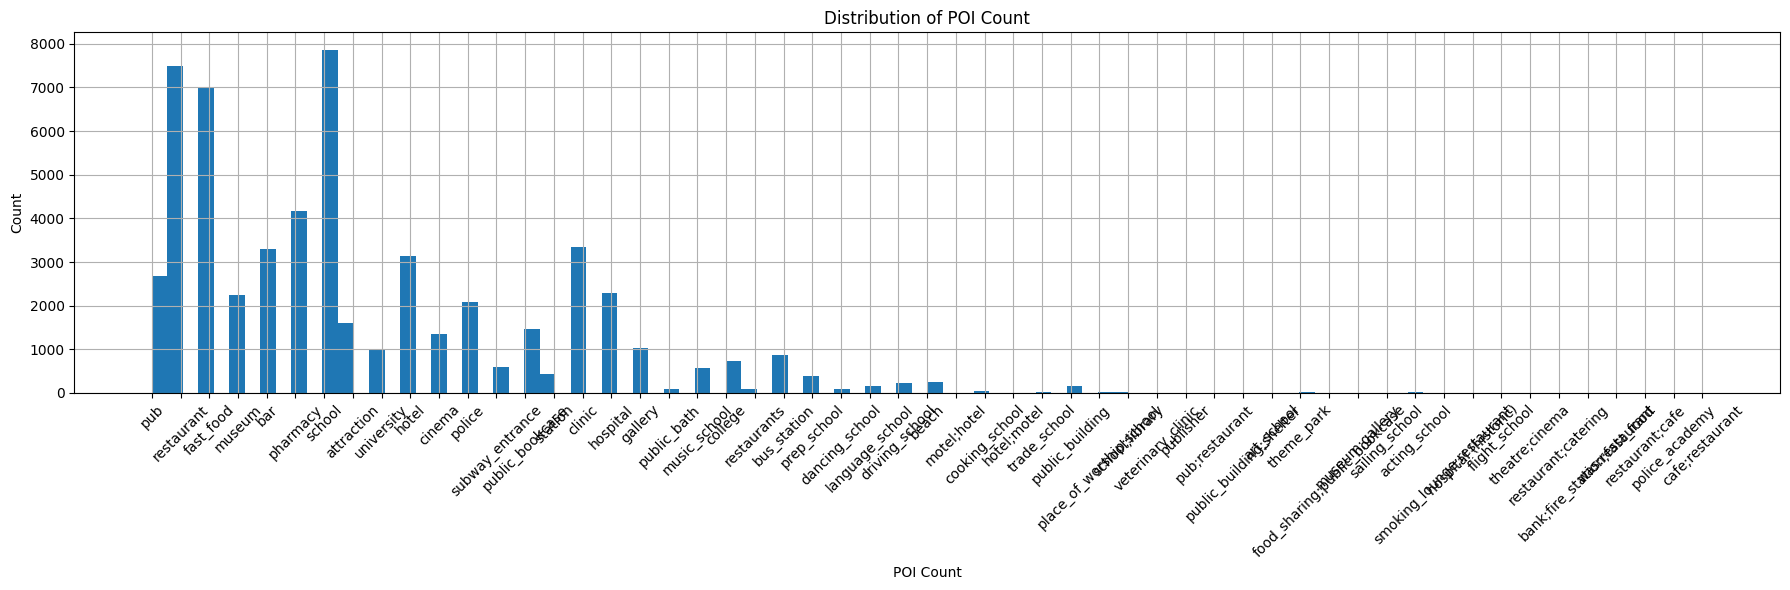

In [999]:
poi_count[["tag", "count"]].groupby("tag").count().sort_values(
    by="tag", ascending=False
)


def plot_poi_distribution(poi_count: pd.DataFrame) -> None:
    """
    Plot the distribution of the POI count in the dataframe.
    The function takes the following parameters:
    - df: the dataframe to plot
    - column: the column to plot
    - title: the title of the plot
    """
    plt.figure(figsize=(18, 6))
    data = poi_count["tag"]
    data.hist(bins=100)
    plt.title("Distribution of POI Count")
    plt.xlabel("POI Count")
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


plot_poi_distribution(poi_count)

In [1000]:
poi_pivot_table = poi_count.pivot_table(
    index="id",
    columns="tag",
    values="count",
    aggfunc="sum",  # or "first" depending on your data
    fill_value=0,
)

# Optionally: Rename columns to include "_count" suffix
poi_pivot_table.columns = [f"{col}_count" for col in poi_pivot_table.columns]

# Reset index if you want `id` as a column
poi_pivot_table

,acting_school_count,art_school_count,attraction_count,bank;fire_station;fast_food_count,bar_count,beach_count,bus_station_count,cafe;restaurant_count,cinema_count,clinic_count,...,school;library_count,smoking_lounge;restaurant_count,station_count,subway_entrance_count,theatre;cinema_count,theme_park_count,trade_school_count,university_count,veterinary_clinic_count,was:restaurant_count
id,,,,,,,,,,,,,,,,,,,,,
5508654087,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5508654149,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
5508654460,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5508654607,0,0,2,0,19,0,0,0,1,1,...,0,0,0,7,0,0,0,2,0,0
5508654638,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5668643363,0,0,0,0,0,0,0,0,0,3,...,0,0,0,0,0,0,0,0,0,0
5668643383,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
5668643398,0,0,0,0,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0


In [1001]:
rent_with_poi = pd.merge(
    rent,
    poi_pivot_table,
    left_on=["id"],
    right_index=True,
    how="left",
)

# Fill missing values in the new columns with 0
new_poi_amenities = rent_with_poi.columns.difference(rent.columns).tolist()
rent_with_poi[new_poi_amenities] = rent_with_poi[new_poi_amenities].fillna(0)
rent_with_poi

,id,bathrooms,bedrooms,price,square_feet,pets_allowed_Cats,"pets_allowed_Cats,Dogs",pets_allowed_Dogs,pets_allowed_No,state_AK,...,school;library_count,smoking_lounge;restaurant_count,station_count,subway_entrance_count,theatre;cinema_count,theme_park_count,trade_school_count,university_count,veterinary_clinic_count,was:restaurant_count
0,5668626833,1.0,0.0,1390,107,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,4.0,0.0,0.0,0.0,1.0,0.0,0.0
1,5659918074,1.0,0.0,925,116,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,9.0,0.0,0.0,0.0,1.0,0.0,0.0
2,5667891676,1.0,0.0,2475,130,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,14.0,108.0,0.0,0.0,0.0,4.0,0.0,0.0
3,5668610290,1.0,0.0,1495,138,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5664571820,1.0,0.0,1695,190,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8485,5668629192,2.0,3.0,2000,1574,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8486,5668624391,2.0,3.0,1549,1574,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8487,5664596429,2.5,2.0,1700,1575,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8488,5664576263,2.0,3.0,1425,1575,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Linear Regression Model

### Analyzing and choosing features for linear regression

In [1002]:
# filtering poi_pivot_table dataset

# Create a filtered DataFrame excluding columns with ";", "(" or ":" in the name
poi_pivot_filtered = poi_pivot_table.loc[
    :, ~poi_pivot_table.columns.str.contains(r"[;(:]", regex=True)
].copy()

poi_pivot_filtered.head()

,acting_school_count,art_school_count,attraction_count,bar_count,beach_count,bus_station_count,cinema_count,clinic_count,college_count,cooking_school_count,...,restaurant_count,restaurants_count,sailing_school_count,school_count,station_count,subway_entrance_count,theme_park_count,trade_school_count,university_count,veterinary_clinic_count
id,,,,,,,,,,,,,,,,,,,,,
5508654087,0,0,0,0,0,0,0,0,0,0,...,3,0,0,1,0,0,0,0,0,0
5508654149,0,0,0,0,0,0,0,1,0,0,...,1,0,0,1,0,0,0,0,0,0
5508654460,0,0,0,1,0,0,0,0,0,0,...,6,0,0,1,0,0,0,0,0,0
5508654607,0,0,2,19,0,0,1,1,1,0,...,114,0,0,3,0,7,0,0,2,0
5508654638,0,0,0,0,0,0,0,0,0,0,...,3,0,0,1,0,0,0,0,0,0


In [ ]:
def get_most_correlateds(
    df: pd.DataFrame, target: str, threshold: float = 0.1
) -> pd.DataFrame:
    """
    Analyzes the correlation of numeric columns with a target variable.
    Prints the heatmap of the correlation matrix.
    Filters the dataset to keep only features with absolute correlation greater than the threshold.
    Prints a horizontal bar chart of the selected correlations.
    Returns the filtered dataset.
    """

    # Select only numeric columns and compute correlation matrix
    numeric_df = df.select_dtypes(include="number")

    # Get correlation of features with the target
    corr_with_target = numeric_df.corr()[target].drop(target)

    # Filter based on absolute correlation > threshold
    selected_series = corr_with_target[abs(corr_with_target) > threshold]
    selected_columns = list(selected_series.index)

    # Preserve 'id' column if it exists
    if "id" in df.columns and "id" not in selected_columns:
        selected_columns.insert(0, "id")

    # Plot barh chart of correlations
    plt.figure(figsize=(8, 6))
    selected_series.sort_values().plot(kind="barh")
    plt.title(f'Features correlated with "{target}" (|corr| > {threshold})')
    plt.xlabel("Correlation")
    plt.grid(True, axis="x", linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.show()

    # Return DataFrame with selected features only
    return df[selected_columns]

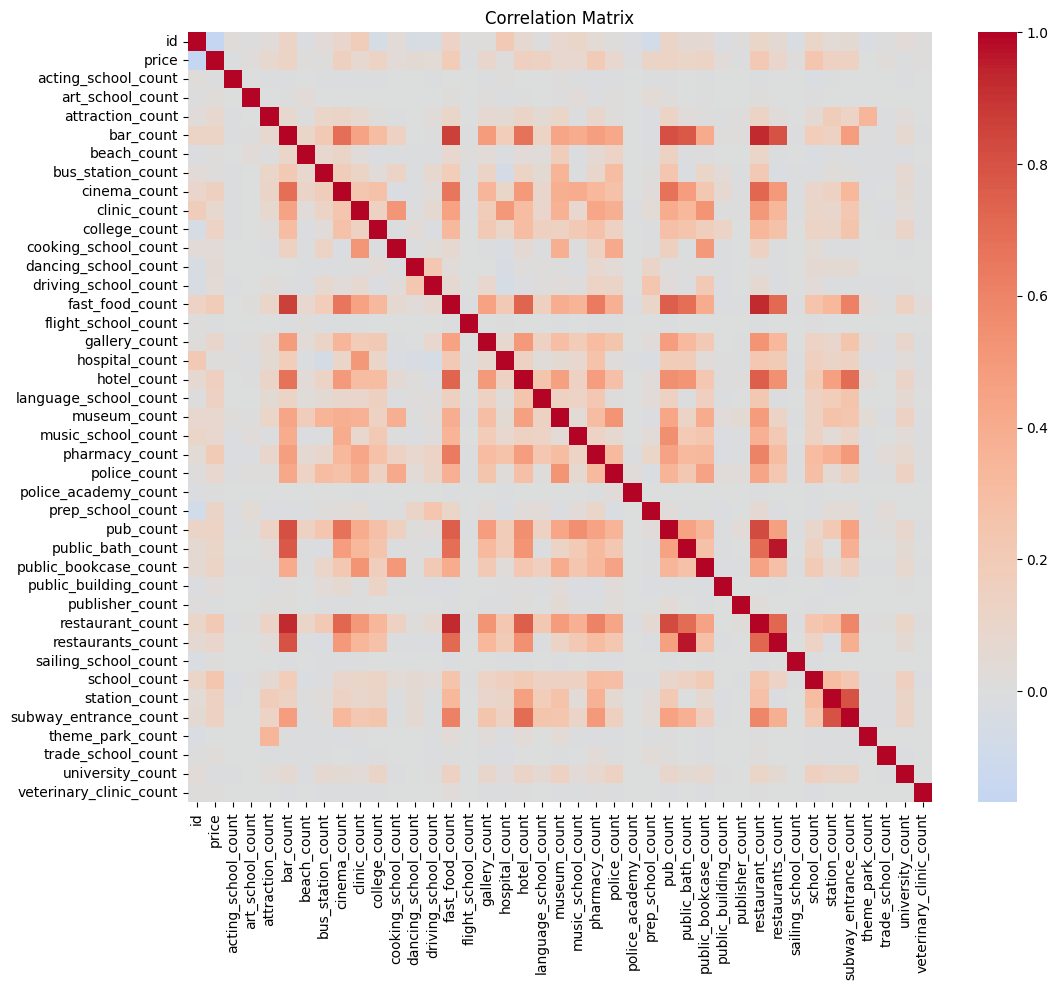

In [1004]:
# analyzing correlation of poi_pivot_filtered with rent["price"]
# creating a temporary merged dataset of poi_pivot_filtered with rent column price
merged_temp = pd.merge(
    rent[["id", "price"]],
    poi_pivot_filtered,
    left_on="id",
    right_index=True,
    how="left",
)

# Fill missing values in the new columns with 0
new_poi_amenities = merged_temp.columns.difference(rent.columns).tolist()
merged_temp[new_poi_amenities] = merged_temp[new_poi_amenities].fillna(0)


# Compute the correlation matrix
corr_matrix = merged_temp.corr()

# Plot the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, cmap="coolwarm", annot=False, fmt=".2f", center=0)
plt.title("Correlation Matrix")
plt.show()

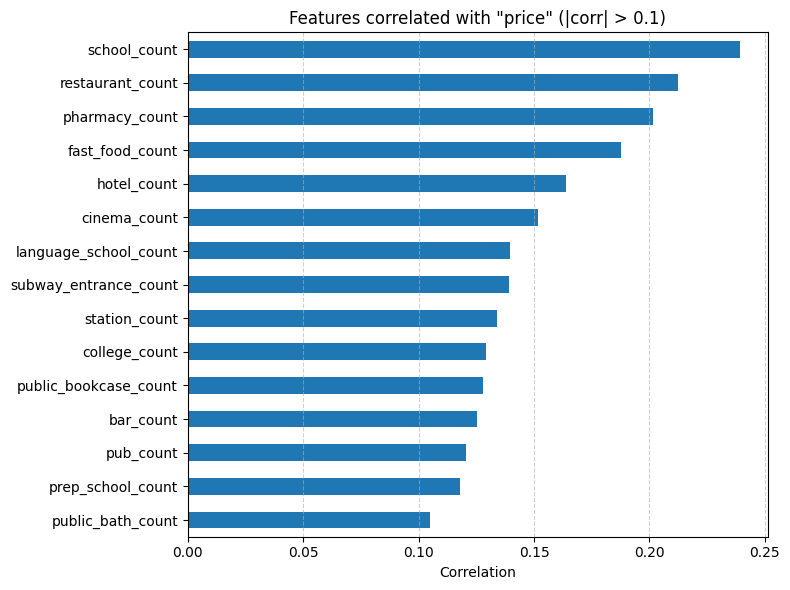

['id', 'bar_count', 'cinema_count', 'college_count', 'fast_food_count', 'hotel_count', 'language_school_count', 'pharmacy_count', 'prep_school_count', 'pub_count', 'public_bath_count', 'public_bookcase_count', 'restaurant_count', 'school_count', 'station_count', 'subway_entrance_count']


,id,bar_count,cinema_count,college_count,fast_food_count,hotel_count,language_school_count,pharmacy_count,prep_school_count,pub_count,public_bath_count,public_bookcase_count,restaurant_count,school_count,station_count,subway_entrance_count
0,5668626833,2.0,1.0,0.0,15.0,9.0,0.0,1.0,0.0,3.0,0.0,1.0,32.0,4.0,1.0,4.0
1,5659918074,69.0,3.0,2.0,79.0,28.0,0.0,4.0,0.0,11.0,1.0,5.0,190.0,7.0,0.0,9.0
2,5667891676,66.0,5.0,3.0,134.0,108.0,0.0,20.0,1.0,32.0,0.0,0.0,376.0,17.0,14.0,108.0
3,5668610290,12.0,1.0,0.0,5.0,2.0,1.0,3.0,0.0,2.0,0.0,1.0,51.0,12.0,0.0,2.0
4,5664571820,12.0,1.0,0.0,5.0,2.0,1.0,3.0,0.0,2.0,0.0,1.0,51.0,12.0,0.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8485,5668629192,0.0,0.0,0.0,6.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,3.0,4.0,0.0,0.0
8486,5668624391,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
8487,5664596429,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
8488,5664576263,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [1005]:
# creates a new dataset with only the poi_pivot features with correlation > 10% with
poi_pivot_filtered_correlated = get_most_correlateds(
    merged_temp, target="price", threshold=0.1
)

# Fix index type to string
poi_pivot_filtered_correlated.index = poi_pivot_filtered_correlated.index.astype(str)

poi_pivot_filtered_correlated

In [1006]:
# merging rent with the poi_pivot_filtered_correlated dataset
rent_linear_regression_df = pd.merge(
    rent, poi_pivot_filtered_correlated, left_on="id", right_index=True, how="left"
)

# Fill missing values in the new columns with 0
new_poi_amenities = rent_linear_regression_df.columns.difference(rent.columns).tolist()
rent_linear_regression_df[new_poi_amenities] = (
    rent_linear_regression_df[new_poi_amenities].fillna(0).infer_objects(copy=False)
)
rent_linear_regression_df

/var/folders/bk/zc2m7bx944nf0pjgprskxq8h0000gn/T/ipykernel_8374/1142476716.py:14: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(0)


,id,id_x,bathrooms,bedrooms,price,square_feet,pets_allowed_Cats,"pets_allowed_Cats,Dogs",pets_allowed_Dogs,pets_allowed_No,...,language_school_count,pharmacy_count,prep_school_count,pub_count,public_bath_count,public_bookcase_count,restaurant_count,school_count,station_count,subway_entrance_count
0,5668626833,5668626833,1.0,0.0,1390,107,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,5659918074,5659918074,1.0,0.0,925,116,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,5667891676,5667891676,1.0,0.0,2475,130,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,5668610290,5668610290,1.0,0.0,1495,138,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5664571820,5664571820,1.0,0.0,1695,190,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8485,5668629192,5668629192,2.0,3.0,2000,1574,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8486,5668624391,5668624391,2.0,3.0,1549,1574,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8487,5664596429,5664596429,2.5,2.0,1700,1575,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8488,5664576263,5664576263,2.0,3.0,1425,1575,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Training linear regression model

### Fiting Models

In [1007]:
# Defining features (X) and target (y)
X = rent_linear_regression_df.drop("price", axis=1)
y = rent_linear_regression_df["price"]

# Split Data into Training and Testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_RATIO, random_state=RANDOM_SEED
)

print(f"\nShape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")


Shape of X_train: (6792, 104)
Shape of X_test: (1698, 104)
Shape of y_train: (6792,)
Shape of y_test: (1698,)


Training the Standard Linear Regression Model Without Scaling

In [1008]:
# Training the Standard Linear Regression Model Without Scaling
linear_model_unscaled = LinearRegression()
linear_model_unscaled.fit(X_train, y_train)

LinearRegression()

Training the Standard Linear Regression Model Scaling

In [1009]:
# Initialize Scaler
scaler = StandardScaler()

# Fit the scaler to the training data and then transform the training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform the test data using the scaler fitted on the training data
X_test_scaled = scaler.transform(X_test)

linear_model_scaled = LinearRegression()
linear_model_scaled.fit(X_train_scaled, y_train)

LinearRegression()

## Model Evaluation

### k-Fold cross-validation

In [1010]:
# Initialize the KFold object
kf = KFold(n_splits=K_FOLDS, shuffle=True, random_state=RANDOM_SEED)

Cross-validation Without scaling

In [1011]:
# Perform k-fold cross-validation using the unscaled linear model
cv_r2_scores_unscaled = cross_val_score(linear_model_unscaled, X_train, y_train, cv=kf)

print("\nCross-Validation R-squared Scores (Unscaled):")
print(cv_r2_scores_unscaled)

# Calculate the mean (average) of the R-squared scores
mean_r2_unscaled = np.mean(cv_r2_scores_unscaled)
# Calculate the standard deviation of the R-squared scores
std_r2_unscaled = np.std(cv_r2_scores_unscaled)

print(f"Mean R-squared (Unscaled): {mean_r2_unscaled:.3f}")
print(f"Standard deviation of R-squared (Unscaled): {std_r2_unscaled:.3f}")


Cross-Validation R-squared Scores (Unscaled):
[0.55995093 0.59793421 0.56823557 0.51863893 0.58674369]
Mean R-squared (Unscaled): 0.566
Standard deviation of R-squared (Unscaled): 0.027


Cross-validation with StandardScaler

In [1012]:
# Perform k-fold cross-validation using the scaled linear model
cv_r2_scores_scaled = cross_val_score(
    linear_model_scaled, X_train_scaled, y_train, cv=kf
)

print("\nCross-Validation R-squared Scores (Scaled):")
print(cv_r2_scores_scaled)

# Calculate the mean (average) of the R-squared scores
mean_r2_scaled = np.mean(cv_r2_scores_scaled)
# Calculate the standard deviation of the R-squared scores
std_r2_scaled = np.std(cv_r2_scores_scaled)

print(f"Mean R-squared (Scaled): {mean_r2_scaled:.3f}")
print(f"Standard deviation of R-squared (Scaled): {std_r2_scaled:.3f}")


Cross-Validation R-squared Scores (Scaled):
[0.55995094 0.59769269 0.56791212 0.51863893 0.58674369]
Mean R-squared (Scaled): 0.566
Standard deviation of R-squared (Scaled): 0.027


### Evalueting Metrics for Training and Testing Set

In [1013]:
def evaluate_model_performance(
    model, X_train, y_train, X_test, y_test, model_name="Model"
):
    """
    Evaluate the performance of a regression model using R², RMSE, NRMSE, and MAE
    on training and testing data.
    Returns a Dictionary with metrics for both training and testing sets
    """
    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # R²
    r2_train = r2_score(y_train, y_train_pred)
    r2_test = r2_score(y_test, y_test_pred)

    # RMSE
    rmse_train = sqrt(mean_squared_error(y_train, y_train_pred))
    rmse_test = sqrt(mean_squared_error(y_test, y_test_pred))

    # Normalized RMSE
    nrmse_train = rmse_train / y_train.mean()
    nrmse_test = rmse_test / y_test.mean()

    # MAE
    mae_train = mean_absolute_error(y_train, y_train_pred)
    mae_test = mean_absolute_error(y_test, y_test_pred)

    return {
        "Model": model_name,
        "R² Train": r2_train,
        "R² Test": r2_test,
        "RMSE Train": rmse_train,
        "RMSE Test": rmse_test,
        "NRMSE Train": nrmse_train,
        "NRMSE Test": nrmse_test,
        "MAE Train": mae_train,
        "MAE Test": mae_test,
    }

Evalueting Train and Testing Set for Unscaled and Scaled Model

In [1014]:
# Evalueting unscaled model
metrics_unscaled = evaluate_model_performance(
    model=linear_model_unscaled,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    model_name="Unscaled",
)

In [1015]:
# Evalueting scaled model
metrics_scaled = evaluate_model_performance(
    model=linear_model_scaled,
    X_train=X_train_scaled,
    y_train=y_train,
    X_test=X_test_scaled,
    y_test=y_test,
    model_name="Scaled",
)

In [1016]:
# Converting scaled and unscaled metrics to DataFrame for viewing
metrics_df = pd.DataFrame([metrics_unscaled, metrics_scaled]).set_index("Model").T
metrics_df

Model,Unscaled,Scaled
R² Train,0.577922,0.577922
R² Test,0.542578,0.542578
RMSE Train,306.910889,306.910889
RMSE Test,307.990367,307.990367
NRMSE Train,0.242680,0.242680
NRMSE Test,0.246088,0.246088
MAE Train,230.150784,230.150784
MAE Test,231.418869,231.418869


## Charts to Result Analysis

In [1017]:
y_train_pred = linear_model_unscaled.predict(X_train)
y_test_pred = linear_model_unscaled.predict(X_test)

### Actual vs. Predicted Plot
Purpose: See how close the model comes to the real values.

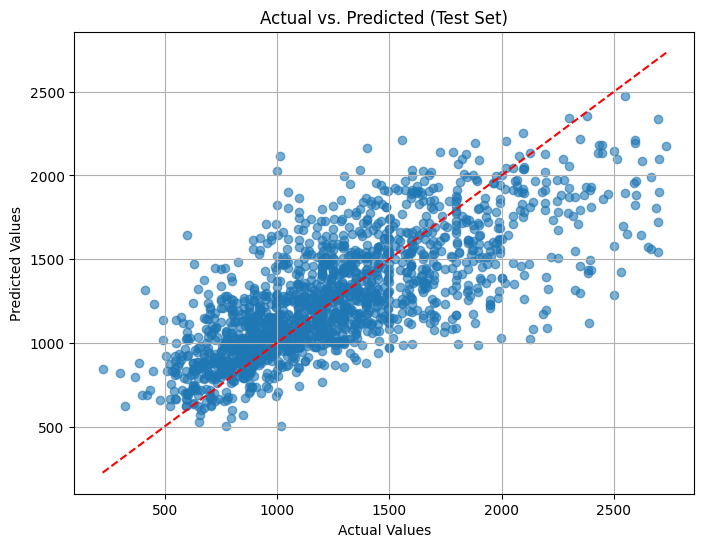

In [1018]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_test_pred, alpha=0.6)
plt.plot(
    [y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--"
)  # Ideal line
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs. Predicted (Test Set)")
plt.grid(True)
plt.show()

### Residual Plot (Error vs. Predicted Value)
Purpose: To see if the residuals are randomly distributed (good regression).

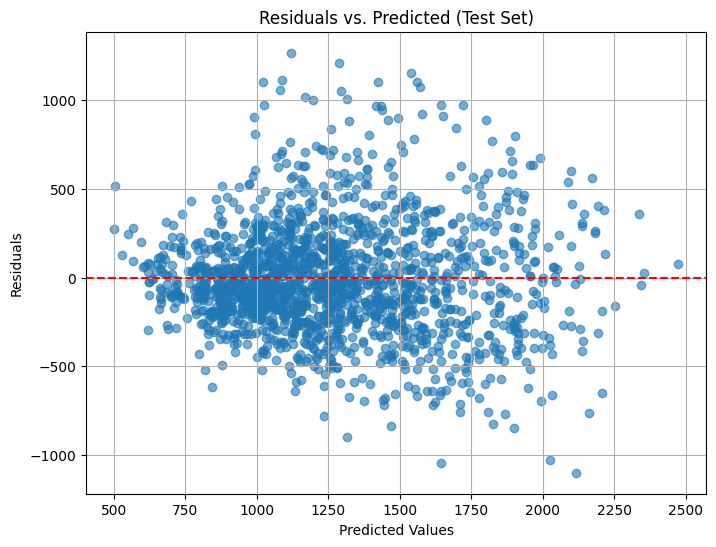

In [1019]:
residuals = y_test - y_test_pred

plt.figure(figsize=(8, 6))
plt.scatter(y_test_pred, residuals, alpha=0.6)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs. Predicted (Test Set)")
plt.grid(True)
plt.show()

### Histogram of Residuals
Purpose: To assess whether residuals follow a normal distribution

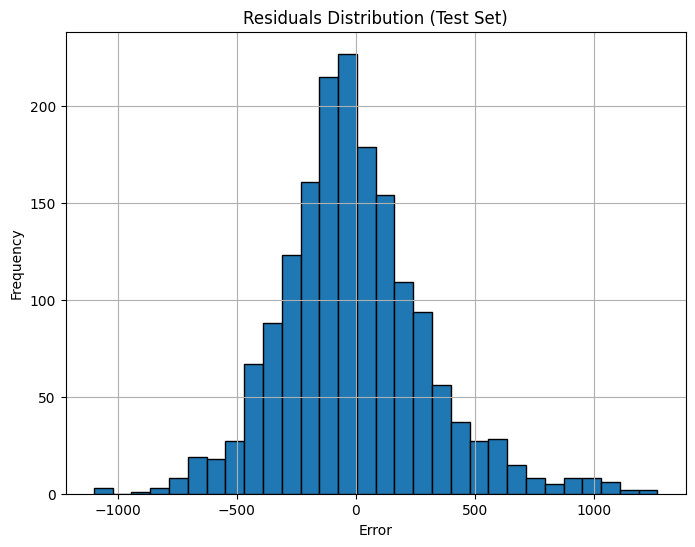

In [1020]:
plt.figure(figsize=(8, 6))
plt.hist(residuals, bins=30, edgecolor="black")
plt.title("Residuals Distribution (Test Set)")
plt.xlabel("Error")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

### QQ Plot of Residuals
Purpose: To check if residuals are normally distributed.

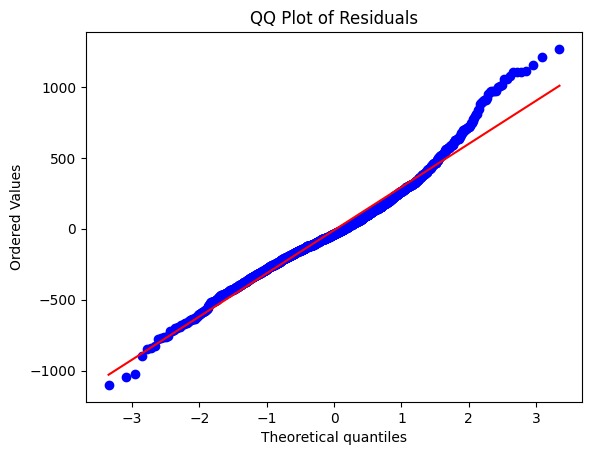

In [1021]:
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("QQ Plot of Residuals")
plt.show()

### Feature Importance (Coefficients from LinearRegression)
In Linear Regression the coefficients represent the feature importance for the Model

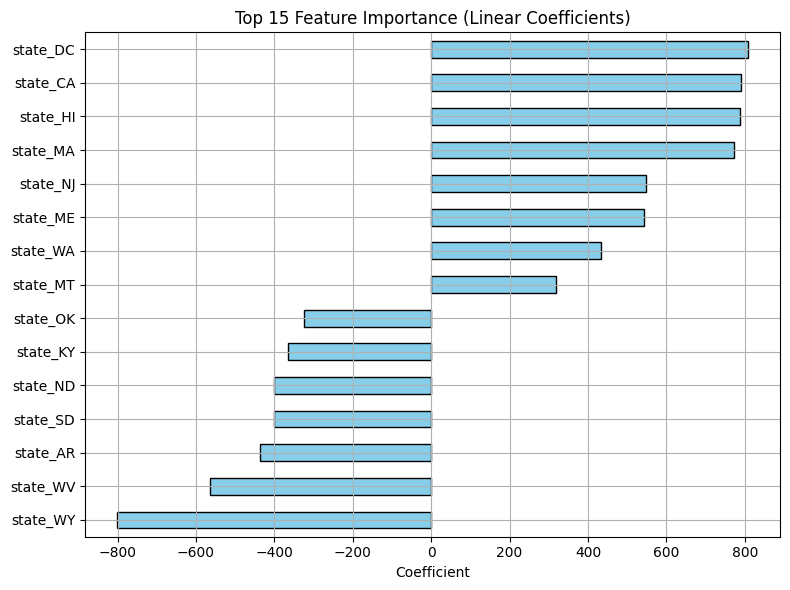

In [1022]:
# creates dataframe with the cofficients
coef_df = pd.Series(linear_model_unscaled.coef_, index=X_train.columns)

# Select top 15 with highest absolute value
top15 = coef_df.reindex(coef_df.abs().sort_values(ascending=False).head(15).index)

# Plotar
top15.sort_values().plot(
    kind="barh", figsize=(8, 6), color="skyblue", edgecolor="black"
)
plt.title("Top 15 Feature Importance (Linear Coefficients)")
plt.xlabel("Coefficient")
plt.grid(True)
plt.tight_layout()
plt.show()